# Phase 1 — Chordonomicon Data Exploration
Explore chord distributions, genre breakdowns, common progressions, and graph statistics.

In [6]:
import re
import itertools
from collections import Counter
import matplotlib


In [2]:
from datasets import load_dataset

ds = load_dataset("ailsntua/Chordonomicon", split="train", streaming=True)
sample = next(iter(ds))
print(sample.keys())   # reveals actual field names
print(sample)          # shows one full row


c:\Users\shawn\anaconda3\envs\chord_transformer\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


dict_keys(['id', 'chords', 'release_date', 'genres', 'decade', 'rock_genre', 'artist_id', 'main_genre', 'spotify_song_id', 'spotify_artist_id'])
{'id': 1, 'chords': '<intro_1> C <verse_1> F C E7 Amin C F C G7 C F C E7 Amin C F G7 C <verse_2> F C E7 Amin C F C G7 C F C E7 Amin C F G7 C <chorus_1> F C F C G C F C E7 Amin C F G7 C <solo_1> D <chorus_2> G D G D A D G D Fs7 Bmin D G A7 D G A7 D', 'release_date': None, 'genres': "'classic country pop'", 'decade': None, 'rock_genre': None, 'artist_id': 'artist_1', 'main_genre': 'pop', 'spotify_song_id': None, 'spotify_artist_id': '4AIEGdwDzPELXYgM5JaEY5'}


In [3]:
# TODO: chord frequency distribution
# TODO: genre breakdown
# TODO: most common bigrams / trigrams
# TODO: sequence length histogram

We'll first do a chord frequencey break down. This is to help us decide on data augmentation strategies, as well as tokenization strategies. As we want to make sure less common chords are represented well enough.

In [ ]:
import re

def split_chords_and_sections(chord_string):
    tokens = chord_string.split()
    sections = []
    chords = []
    for t in tokens:
        if t.startswith("<") and t.endswith(">"):
            sections.append(re.sub(r'_\d+$', '', t))  # <verse_1> → <verse>
        else:
            chords.append(t)
    return chords, sections

def parse_quality(chord):
    m = _ROOT_RE.match(chord)
    if not m:
        return "unknown"
    suffix = m.group(2)
    suffix = suffix.split("/")[0]   # strip bass note e.g. min/G -> min
    return QUALITY_MAP.get(suffix, "other")


In [7]:

quality_counter = Counter()

for example in itertools.islice(ds, 50_000):
    tokens = example["chords"].split()
    for t in tokens:
        if not (t.startswith("<") and t.endswith(">")):  # skip section markers
            quality_counter[parse_quality(t)] += 1

print(f"Unique qualities: {len(quality_counter)}")

Unique qualities: 486


We will analyze the result from the first 50,000 chord progressions


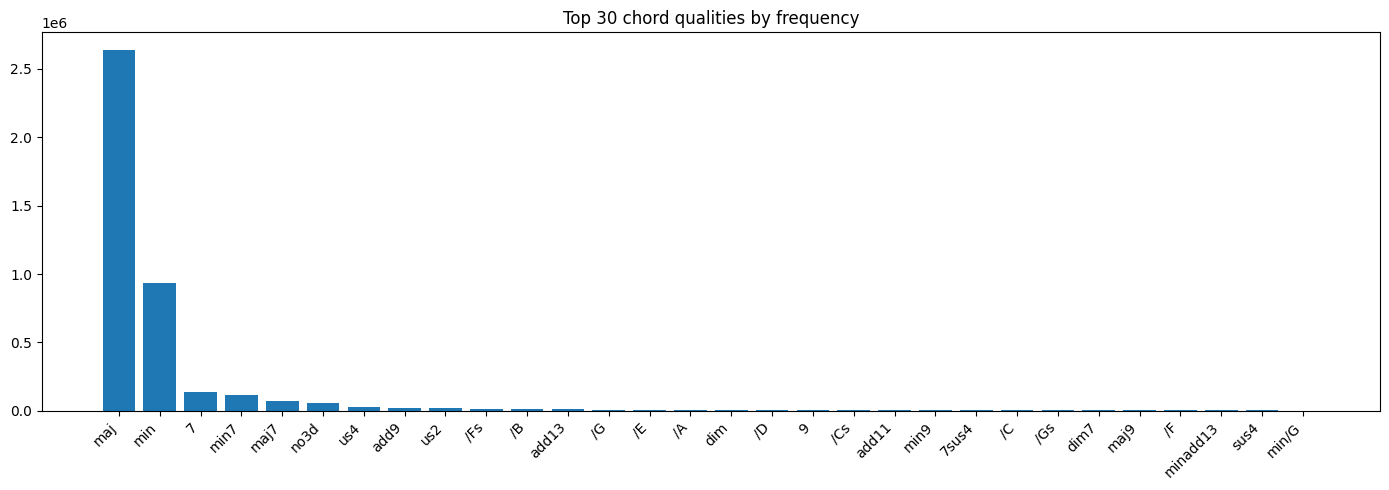

Qualities appearing < 100 times: 351 / 486
Qualities appearing < 500 times: 430 / 486
Qualities appearing < 1000 times: 441 / 486


In [8]:
# Cell 3 — plot
import matplotlib.pyplot as plt

top = quality_counter.most_common(30)
labels, counts = zip(*top)

plt.figure(figsize=(14, 5))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Top 30 chord qualities by frequency")
plt.tight_layout()
plt.show()

# Tail analysis — answers atomic vs decomposed question
for threshold in [100, 500, 1000]:
    rare = sum(1 for c in quality_counter.values() if c < threshold)
    print(f"Qualities appearing < {threshold} times: {rare} / {len(quality_counter)}")


Notice that the tail is very light in general. More complex and "niche" chord qualities get captured less compared to common chord qualities. This tells us we will have to use some techniques during training to make notice on the uncommon chord sequences more. 

We will use the following methods:
- Token decomposition
- Focal loss
- Label smoothing
- Sequence-level oversampling
- Chord family collapse	
- Curriculum learning	

We'll move onto observing the sequence lengths.

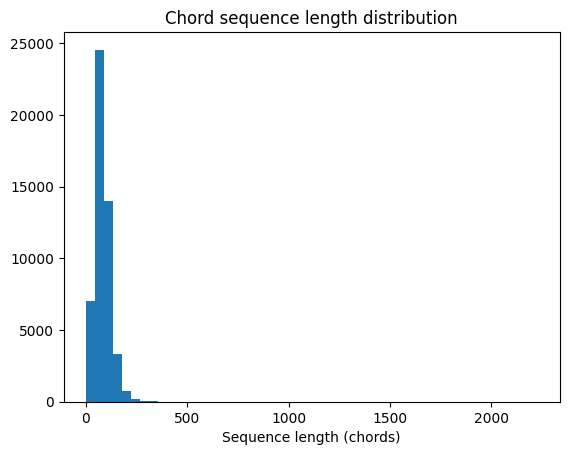

Median: 77
95th percentile: 152
Max: 2226


In [9]:
lengths = []
for example in itertools.islice(ds, 50_000):
    chords = [t for t in example["chords"].split()
              if not (t.startswith("<") and t.endswith(">"))]
    lengths.append(len(chords))

import matplotlib.pyplot as plt
plt.hist(lengths, bins=50)
plt.xlabel("Sequence length (chords)")
plt.title("Chord sequence length distribution")
plt.show()

print(f"Median: {sorted(lengths)[len(lengths)//2]}")
print(f"95th percentile: {sorted(lengths)[int(len(lengths)*0.95)]}")
print(f"Max: {max(lengths)}")


We can see that on average most songs have a sequence length less than 152 as noted by the 95th percentile. With the median song have a length of 77 chords. As such we will make our max sequence length 152, this means that we will calculate 152 * 152 total attention scores each time.

Key Takeaways:
- Identified the distribution of chords qualities
    - Motivates some training methods and changes in the transformer to account for light tails
- Found a good maximum sequence length for our transformer
    - Leads us to find a good length which doesn't compromise the robustness of sequences and length of training

Now lets do some analysis of voicings specifically

In [11]:
from collections import Counter
import re

_ROOT_RE = re.compile(r'^([A-G](?:s(?!us)|b)?)(.*)$')

# Base qualities we already know map to families
BASE_QUALITIES = {
    "", "maj", "M", "min", "m",
    "7", "maj7", "M7", "min7", "m7",
    "dim", "o", "dim7", "o7", "hdim7",
    "aug", "+",
    "sus2", "sus4", "sus",
    "6", "maj6", "min6", "m6",
    "9", "maj9", "min9", "m9",
    "11", "min11", "13", "min13",
}

voicing_counter = Counter()

for example in itertools.islice(ds, 50_000):
    tokens = example["chords"].split()
    for t in tokens:
        if t.startswith("<") and t.endswith(">"):
            continue
        m = _ROOT_RE.match(t)
        if m:
            suffix = m.group(2).split("/")[0]  # strip slash chords e.g. min/G -> min
            if suffix not in BASE_QUALITIES:
                voicing_counter[suffix] += 1

print(f"Unique voicing suffixes not in base set: {len(voicing_counter)}")
for suffix, count in voicing_counter.most_common(20):
    print(f"  {suffix:20s} {count}")

Unique voicing suffixes not in base set: 32
  no3d                 55107
  add9                 24834
  add13                14069
  add11                5267
  7sus4                4656
  minadd13             3038
  7sus2                1326
  minadd9              1233
  minmaj7              920
  maj7sus2             838
  majs9                643
  augmaj7              566
  7b9                  556
  maj13                390
  minadd11             337
  maj911s              327
  maj7sus4             146
  maj11                146
  13b                  67
  augmaj9              45


Lets have the following voicing tokens:
VOICING_TOKENS = [
    "none",         # no voicing detail
    "no3d",         # power chord
    "add9",
    "add13",
    "add11",
    "7sus4",
    "7sus2",
    "minadd13",
    "minadd9",
    "minmaj7",
    "7b9",
    "other_voicing",  # catch-all for rare ones
]